In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="openai/gpt-oss-20b")

In [33]:
# define state
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    rating: int


In [6]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title from state
    title = state['title']

    # call llm and generate outline
    prompt = f"Create a detailed outline for a blog post for the following title: {title}"
    outline = model.invoke(prompt).content

    # update state
    state["outline"] = outline

    return state

In [20]:
def create_blog(state: BlogState) -> BlogState:

    #fetch title and outline from state
    title = state["title"]
    outline = state["outline"]

    # call llm and generate blog content
    prompt = f"Write a blog for me on {title} using the following outline: \n {outline}"
    content = model.invoke(prompt).content

    # update state
    state["content"] = content

    return state

In [39]:
def evaluate_blog(state: BlogState) -> BlogState:

    # fetch content and outline from state
    content = state["content"]
    outline = state["outline"]

    # evaluate the blog content
    prompt = f"Based on the outline: \n {outline} just only rate my blog: \n {content} no suggestions or explanations needed"
    rating  = model.invoke(prompt).content

    # update state
    state["rating"] = rating

    return state

In [40]:
# create graph
graph = StateGraph(BlogState)

# add nodes to the graph
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node("evaluate_blog", evaluate_blog)

# add edges to the graph
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

# compile graph

workflow = graph.compile()

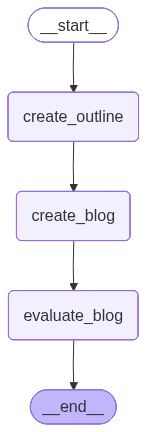

In [41]:
workflow

In [42]:
# execute workflow
initial_state = {"title": "Rise of AI"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI', 'outline': '## Blog Post Outline  \n**Title:** *Rise of AI: How Artificial Intelligence Is Redefining the 21st Century*\n\n---\n\n### 1. Hook & Opening Paragraph\n- **Attention‑grabbing statistic** (e.g., “AI is projected to contribute up to $15.7 trillion to the global economy by 2030.”)  \n- **Personal anecdote or scenario** (e.g., a morning routine guided by a smart assistant).  \n- **Thesis statement**: The rapid ascent of AI is reshaping industries, societies, and our very sense of what it means to be human.\n\n---\n\n### 2. Historical Context\n| Sub‑Section | Key Points |\n|-------------|------------|\n| **Early Foundations** | • Turing Test (1950) <br>• Dartmouth Workshop (1956) |\n| **First AI Winter** | • Over‑optimism & funding gaps <br>• Limits of rule‑based systems |\n| **Re‑emergence** | • Machine learning breakthroughs (1990s) <br>• Rise of big data and GPUs |\n| **Modern Milestones** | • Deep Blue vs. Kasparov (1997) <br>• AlphaGo (2016) <br>• GPT

In [43]:
print(final_state["rating"])

**Overall Rating: 8.5/10**

**What Worked Well**
- **Strong Hook** – The opening statistic and relatable morning‑routine anecdote instantly capture attention.
- **Clear Structure** – The outline‑style headings and tables make the content easy to scan and digest.
- **Balanced Depth** – Technical explanations are paired with real‑world examples and impact metrics.
- **Engagement Elements** – Interactive prompts (timeline slider, debate question, poll) invite reader participation.
- **Actionable Take‑aways** – The CTA section gives concrete steps for individuals, businesses, and policymakers.

**Areas for Enhancement**
1. **Visual Integration** – While suggestions are noted, adding a few sample graphics (e.g., a mini timeline or infographic) would demonstrate the final look.
2. **Citation Footnotes** – Adding inline citations (e.g., for the $15.7 trillion figure or accuracy stats) boosts credibility.
3. **Diversity of Sources** – Including a few non‑Western perspectives, especially in the

In [25]:
print(final_state["content"])

# Rise of AI: From Sci‑Fi to Everyday Reality  

---

## 1. Hook & Context (≈150 words)

Picture this: it’s 2024, you walk into your kitchen and a sleek, silent robot greets you. “Good morning, Maya. Your schedule today: 9 a.m. – virtual boardroom, 12 p.m. – lunch with the AI‑generated meal planner, 4 p.m. – a quick walk‑through of the smart‑home energy dashboard.” The robot has already pulled in your calendar, the city traffic feed, and the latest weather model to adjust the HVAC, your commute, and even your lunch order—all in real time.  

That scene is no longer a plot point in a science‑fiction film; it’s the new normal. According to IDC, the global AI market surpassed **$200 billion** in 2024, and a **70 %** survey of enterprises worldwide reported that AI has been integrated into at least one core business function.  

**Thesis:** Artificial Intelligence is no longer a niche laboratory curiosity—it’s the engine that’s reshaping every industry, culture, and personal experience we 